## Importing the data

In [1]:
import pandas as pd

# Load the data CSV file
df2 = pd.read_csv("Greenhouse Pathogenicity Data_2.csv")

# Preview the data

print("Second dataset:")
display(df2.head())

Second dataset:


,Unnamed: 0,Unnamed: 1,R1,Unnamed: 3,Unnamed: 4,R2,Unnamed: 6,Unnamed: 7,R3,Unnamed: 9,Unnamed: 10,R4,Unnamed: 12,Unnamed: 13,R5,Unnamed: 15,Unnamed: 16
0,Group,Isolate,L,RT,%,L,RT,%,L,RT,%,L,RT,%,L,RT,%
1,J2,AT4-25-12,NaN,NaN,100,5,12,41.67,5,12,41.67,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,AN6-25-13,2,3,66.67,14,16,87.5,4,4,100,NaN,NaN,NaN,NaN,NaN,NaN
3,B,CW12-25-01,NaN,NaN,100,NaN,NaN,100,5,5,100,1,1,100,NaN,NaN,NaN
4,J4,GDY11-25-03,0,22,0,NaN,NaN,100.00,0,16,0.00,NaN,NaN,NaN,NaN,NaN,NaN


## Transform the data from wide form to long form for analysis

In [3]:
import pandas as pd

# Load CSV file directly
df = pd.read_csv("Greenhouse Pathogenicity Data_2.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Identify replicate blocks
rep_map = {
    "R1": (2, 5),
    "R2": (5, 8),
    "R3": (8, 11),
    "R4": (11, 14),
    "R5": (14, 17)
}

long_data = []

for rep, (start, end) in rep_map.items():
    sub = df.iloc[:, [0, 1] + list(range(start, end))].copy()
    sub.columns = ["Group", "Isolate", "L", "RT", "Percent"]
    sub["Rep"] = rep
    long_data.append(sub)

long_df = pd.concat(long_data, ignore_index=True)

# Convert numeric columns safely
for col in ["L", "RT", "Percent"]:
    long_df[col] = pd.to_numeric(long_df[col], errors="coerce")

print(long_df.head())
print (long_df)

   Group      Isolate    L    RT  Percent Rep
0  Group      Isolate  NaN   NaN      NaN  R1
1     J2    AT4-25-12  NaN   NaN   100.00  R1
2    NaN    AN6-25-13  2.0   3.0    66.67  R1
3      B   CW12-25-01  NaN   NaN   100.00  R1
4     J4  GDY11-25-03  0.0  22.0     0.00  R1
     Group      Isolate    L    RT  Percent Rep
0    Group      Isolate  NaN   NaN      NaN  R1
1       J2    AT4-25-12  NaN   NaN   100.00  R1
2      NaN    AN6-25-13  2.0   3.0    66.67  R1
3        B   CW12-25-01  NaN   NaN   100.00  R1
4       J4  GDY11-25-03  0.0  22.0     0.00  R1
..     ...          ...  ...   ...      ...  ..
265      A    AT4-25-06  NaN   NaN      NaN  R5
266     J3   CS18-25-06  NaN   NaN      NaN  R5
267      D    ANG-25-03  NaN   NaN      NaN  R5
268     J1   ANG6-25-12  NaN   NaN      NaN  R5
269      B   BT15-25-10  NaN   NaN      NaN  R5

[270 rows x 6 columns]


## Run ANOVA (analysis of variance)

In [22]:

# --- install (safe inside Jupyter) ---
import sys
!{sys.executable} -m pip install statsmodels

# --- imports ---
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

# --- ANOVA model ---
model = ols("Percent ~ C(Isolate)", data=long_df).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

# --- display results ---
print(anova_table)




[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
                  sum_sq    df         F    PR(>F)
C(Isolate)  79374.805780  45.0  2.224679  0.000597
Residual    73737.062232  93.0       NaN       NaN


## Tukey-test results


===== ANOVA RESULTS =====
                  sum_sq    df         F    PR(>F)
C(Isolate)  79374.805780  45.0  2.224679  0.000597
Residual    73737.062232  93.0       NaN       NaN

===== TUKEY HSD RESULTS =====
       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1      group2   meandiff p-adj    lower    upper   reject
-----------------------------------------------------------------
  AN6-25-09   AN6-25-12  18.9022    1.0  -75.1838 112.9883  False
  AN6-25-09   ANG-25-03  37.6583    1.0   -67.533 142.8497  False
  AN6-25-09   ANG-25-10 -21.8533    1.0 -115.9394  72.2327  False
  AN6-25-09   ANG-26-08  -3.3333    1.0  -97.4194  90.7527  False
  AN6-25-09  ANG6-25-12  20.1511    1.0  -67.8583 108.1606  False
  AN6-25-09   AT4-25-03  37.1706    1.0  -56.9154 131.2566  False
  AN6-25-09   AT4-25-06  12.5911    1.0  -81.4949 106.6771  False
  AN6-25-09   AT4-25-12  25.5567    1.0  -68.5294 119.6427  False
  AN6-25-09  BCN2-25-06  38.5167 0.9999  -55.5694 132.6027  Fal

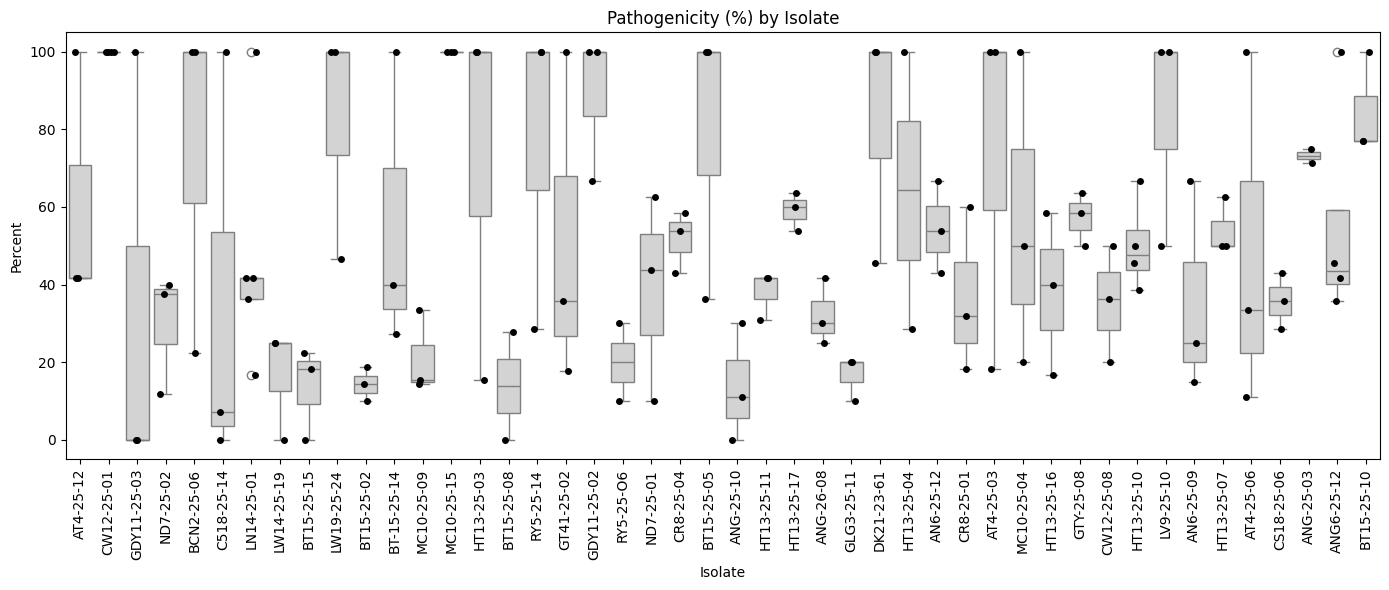

In [23]:
# =========================
# 1. IMPORTS
# =========================
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# 2. CLEAN DATA
# =========================
long_df = long_df.dropna(subset=["Isolate", "Percent"])
long_df["Isolate"] = long_df["Isolate"].astype(str)

# =========================
# 3. ANOVA (Isolate effect)
# =========================
model = ols("Percent ~ C(Isolate)", data=long_df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("\n===== ANOVA RESULTS =====")
print(anova_table)

# =========================
# 4. TUKEY HSD
# =========================
tukey = pairwise_tukeyhsd(
    endog=long_df["Percent"],
    groups=long_df["Isolate"],
    alpha=0.05
)

print("\n===== TUKEY HSD RESULTS =====")
print(tukey)

# =========================
# 5. PLOT (Box + Dot plot)
# =========================
plt.figure(figsize=(14,6))

sns.boxplot(data=long_df, x="Isolate", y="Percent", color="lightgray")
sns.stripplot(data=long_df, x="Isolate", y="Percent", color="black", jitter=0.2)

plt.xticks(rotation=90)
plt.title("Pathogenicity (%) by Isolate")
plt.ylabel("Percent")
plt.tight_layout()
plt.show()


## Save long file in a csv format

In [24]:
long_df.to_csv("Greenhouse_Pathogenicity_Long_Format.csv", index=False)